In [ ]:
from zanj import ZANJ
from maze_dataset import MazeDataset, MazeDatasetConfig
from maze_dataset.generation import LatticeMazeGenerators, GENERATORS_MAP

GENERATORS: list[tuple[str, dict]] = [
    ("gen_dfs", dict()),
    ("gen_wilson", dict()),
    ("gen_dfs_percolation", dict(p=0.2)),
    ("gen_dfs_percolation", dict(p=0.4))
]

LOCAL_DATA_PATH: str = "data/"
DATASETS: dict[int, list[MazeDataset]] = dict()
zanj: ZANJ = ZANJ(external_list_threshold=256)
for grid_n in [32,64,128]:
	DATASETS[grid_n] = list()
	for gen_name, gen_kwargs in GENERATORS:
		# print(gen_name)
		print(f"Generating {gen_name} for grid_n={grid_n}")
		DATASETS[grid_n].append(MazeDataset.from_config(
			MazeDatasetConfig(
				name="demo",
				maze_ctor=GENERATORS_MAP[gen_name],
				grid_n=grid_n,
				n_mazes=8,
				maze_ctor_kwargs=gen_kwargs,
			),
			local_base_path=LOCAL_DATA_PATH + str(grid_n) + '/',
			load_local=False,
			verbose=False,
			zanj=zanj,
		))

Generating gen_dfs for grid_n=32
Generating gen_wilson for grid_n=32
Generating gen_dfs_percolation for grid_n=32
Generating gen_dfs_percolation for grid_n=32
Generating gen_dfs for grid_n=64
Generating gen_wilson for grid_n=64
Generating gen_dfs_percolation for grid_n=64
Generating gen_dfs_percolation for grid_n=64
Generating gen_dfs for grid_n=128
Generating gen_wilson for grid_n=128
Generating gen_dfs_percolation for grid_n=128
Generating gen_dfs_percolation for grid_n=128


['__abstractmethods__', '__annotations__', '__class__', '__copy__', '__dataclass_fields__', '__dataclass_params__', '__dataclass_transform__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_as_adj_list_tokens', '_as_ascii_grid', '_as_coords_and_special_AOTP', '_as_pixels_bw', '_as_tokens', '_from_pixel_grid_bw', '_from_pixel_grid_with_positions', '_from_tokens_AOTP', '_properties_to_serialize', 'as_adj_list', 'as_adj_list_tokens', 'as_ascii', 'as_pixels', 'as_tokens', 'connection_list', 'coord_degrees', 'diff', 'find_shortest_path', 'from_adj_list', 'from_ascii', 'from_pixels', 'from_tokens', 'gen_connected_component_from', 'generate_random_path'

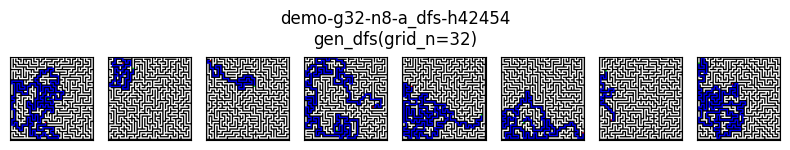

In [25]:
from maze_dataset.plotting import plot_dataset_mazes, print_dataset_mazes
for g, ds_list in DATASETS.items():
    for ds in ds_list:
        print(dir(ds[0].maze))
        print(ds[0].as_pixels(False, False))
        plot_dataset_mazes(ds)
        break
    break

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
a = None
i=0
output_shape = (64, 64)
num = 10
map64 = []
map128 = []
map256 = []
output = np.zeros((num, output_shape[0], output_shape[1]))
for g, ds_list in DATASETS.items():
    for ds in ds_list:
        a = ds
        for idx in range(len(ds)):
            
            map = ds[idx].as_pixels(False, False)
            # Convert RGB to grayscale manually (simple average)
            gray = np.mean(map, axis=2)  # shape: (64, 64)

            # Binary threshold (you can change 127 to other threshold values)
            binary = (gray > 127).astype(np.uint8) * 1  # shape: (64, 64)
            if map.shape[0] == 65:
                tmp_64_map = binary[:64,:64].copy()
                map64.append(tmp_64_map)
            if map.shape[0] == 129:
                tmp_128_map = binary.copy()
                map128.append(tmp_128_map)
            if map.shape[0] == 257:
                tmp_256_map = binary.copy()
                map256.append(tmp_256_map)

map_64_arr = np.array(map64)
map_128_arr = np.array(map128)
map_256_arr = np.array(map256)
# save data
np.savez_compressed('map_64.npz', map_64_arr)
np.savez_compressed('map_128.npz', map_128_arr)
np.savez_compressed('map_256.npz', map_256_arr)

            
            

